In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import pandas as pd
from scipy.optimize import root
from scipy.optimize import brentq
import time


In [32]:
X_train_full = np.load('X_train.npy')
X_val_full = np.load('X_vals.npy')
Y_train_full = np.load('Y_train.npy')
Y_val_full = np.load('Y_val.npy')
s_full = np.load('str.npy')


In [33]:
print(X_train_full.shape, X_val_full.shape)
print(Y_train_full.shape, Y_val_full.shape)
print(s_full.shape)

(60000, 128) (4000, 128)
(60000,) (4000,)
(60000,)


In [34]:
unique_labels = np.sort(np.unique(Y_val_full).astype(int))
labels_frac = np.array([(Y_val_full == unique_labels[i]).sum() for i in range(len(unique_labels))])/len(Y_val_full)
labels_frac

array([0.25, 0.25, 0.25, 0.25])

In [35]:
def f(w, X, Xc, mu, beta_cov, Sigma, alpha, tau, s):
    r = X.T.dot(w)
    diff = r - mu
    g1 = diff.dot(diff)

    Cw = Xc.T.dot(Xc * w[:, None])
    E = Cw - Sigma
    g2 = beta_cov * np.sum(E * E)

    g3 = -alpha * (s.dot(w))
    g4 = tau * np.sum(np.abs(w))

    return g1 + g2 + g3 + g4

def grad_g(y, X, mu, Sigma, alpha, beta_cov, s,M):
    r=X.T.dot(y)-mu
    g1=2*X.dot(r)
    C=M.T.dot(M*y[:,None])-Sigma
    tmp=M.dot(C)
    g2=2*beta_cov*np.sum(M*tmp,axis=1)
    return g1+g2-alpha*s

def proj_simplex(y, a=1.0):
    u = np.sort(y)[::-1]
    css = np.cumsum(u)
    rho_candidates = u - (css - a) / (np.arange(1, len(y) + 1))
    rho = np.nonzero(rho_candidates > 0)[0][-1]
    theta = (css[rho] - a) / (rho + 1.0)
    return np.maximum(y - theta, 0.0)

def proj_class_sum(u, classes, idx_list, lowers, uppers, sizes):
    u2 = u.copy()
    for c, mask in zip(classes, idx_list):
        s     = u[mask].sum()
        lower = lowers[c]
        upper = uppers[c]
        if s < lower:
            u2[mask] += (lower - s) / sizes[c]
        elif s > upper:
            u2[mask] -= (s - upper) / sizes[c]
    return u2

def project_C(v, classes, idx_list, lowers, uppers, sizes, max_iters=50, tol=1e-4):
    x = v.copy()
    p = np.zeros_like(v)
    q = np.zeros_like(v)
    residuals = []

    for _ in range(max_iters):
        y = proj_simplex(x + p)
        p = (x + p) - y
        x_new = proj_class_sum(y+q, classes, idx_list, lowers, uppers, sizes)
        q = (y + q) - x_new
        res = np.linalg.norm(x_new - x)
        residuals.append(res)
        if res < tol:
            return x_new, residuals

        x = x_new

    return x, residuals

def prox_l1(v, tau, step):
    z = np.sign(v) * np.maximum(np.abs(v) - step*tau, 0)
    return z

def fista(X, mu, Sigma, s, alpha, beta_cov, tau, labels, p_c, delta, step=10, max_iter=1000):
    n = X.shape[0]
    w = np.ones(n) / n
    z = w.copy()
    q = 1.0
    step=step
    M  = X - mu  
    
    classes   = np.unique(labels)
    idx_list  = [(labels==c) for c in classes]
    lowers    = {c: p_c[c] - delta for c in classes}
    uppers    = {c: p_c[c] + delta for c in classes}
    class_sizes     = {c: mask.sum() for c,mask in zip(classes, idx_list)}    
    
    for _ in range(max_iter):
        g = grad_g(z, X, mu, Sigma, alpha, beta_cov, s,M)
        fz = f(z, X, M, mu, beta_cov, Sigma, alpha, tau, s)
        while True:
            w_temp = prox_l1(z - step*g, tau, step)
            w_temp,_ = project_C(w_temp, classes, idx_list, lowers, uppers, class_sizes)
            fnext = f(w_temp, X, M, mu, beta_cov, Sigma, alpha, tau, s)
            if fnext <= fz + g.dot(w_temp - z) + 1/(2*step)* np.linalg.norm(w_temp - z)**2:
                
                break
            step *= 0.8
        
        q_next = (1 + np.sqrt(1 + 4 * q**2))/ 2
        z = w_temp + (q - 1)/q_next*(w_temp - w)
        w, q = w_temp, q_next
        step = step / 0.8
        diff = fnext - fz
        if np.abs(diff) < 1e-3:
            break
    return w

In [36]:
size = 60000
X_train = X_train_full[:size]
Y_train = Y_train_full[:size]
X_val = X_val_full[:size]
Y_val = Y_val_full[:size]
s = s_full[:size]
print(X_train.shape, X_val.shape)
print(Y_train.shape, Y_val.shape)
print(s.shape)

n = X_train.shape[0]
XV_mean = np.mean(X_val, axis=0)
XT_mean = np.mean(X_train, axis=0)
Xc_train = X_train - XV_mean
Xc_Val = X_val - XV_mean

unique_labels = np.sort(np.unique(Y_val).astype(int))
labels_frac = np.array([(Y_val == unique_labels[i]).sum() for i in range(len(unique_labels))])/len(Y_val)
print(labels_frac)

target_mu = XV_mean
target_S = Xc_Val.T @ Xc_Val / len(X_val)

(60000, 128) (4000, 128)
(60000,) (4000,)
(60000,)
[0.25 0.25 0.25 0.25]


In [37]:
labels_frac_train = np.bincount(Y_train) / len(Y_train)
labels_frac_val   = np.bincount(Y_val)   / len(Y_val)
print(labels_frac_train)
print(labels_frac_val)


[0.25 0.25 0.25 0.25]
[0.25 0.25 0.25 0.25]


In [58]:
import time
s_obj = s/np.linalg.norm(s)
beta = 3
lambd = 0.3
alpha = 0
delta = 0.1
start_time = time.time()
w_estimated = fista(X_train, target_mu, target_S, s_obj, alpha, beta, lambd, Y_train, labels_frac, delta)
end_time = time.time()

print(f"Execution time: {end_time - start_time} seconds")
print(sum(w_estimated))
print(min(w_estimated))
print(max(w_estimated))
f(w_estimated, X_train, X_train-target_mu, target_mu, beta, target_S, alpha, lambd, s_obj)

Execution time: 32.87926387786865 seconds
1.0000000000000187
0.0
6.989641845353781e-05


0.44184435071945954

In [54]:
import os

k = [1,10,15,25,50]
for ki in k:
    top_count = max(1, int(n * ki / 100))
    print(f"Top {top_count} indices_s ({ki}%)")
    top_k_indices = np.argsort(w_estimated)[-top_count:][::-1]
    np.savetxt(f"top_{ki}pct_indices_s.txt", top_k_indices, fmt='%d')
    

Top 600 indices_s (1%)
Top 6000 indices_s (10%)
Top 9000 indices_s (15%)
Top 15000 indices_s (25%)
Top 30000 indices_s (50%)


In [55]:
for i in range(len((unique_labels))):
    mask = (Y_train == unique_labels[i]).astype(int)
    mask = np.reshape(mask, (n, 1))
    print(mask.T@w_estimated)

[0.2454725]
[0.25072428]
[0.24582528]
[0.25797794]


In [56]:
import numpy as np
import os

k = [1, 10, 15, 25, 50]
for ki in k:
    top_count = max(1, int(n * ki / 100))
    print(f"\nTop {top_count} weights ({ki}%)")

    # Get indices of top-k weights
    top_k_indices = np.argsort(w_estimated)[-top_count:][::-1]
    #np.savetxt(f"top_{ki}pct_indices_s.txt", top_k_indices, fmt='%d')

    # Get top-k weights and corresponding labels
    top_k_weights = w_estimated[top_k_indices]
    top_k_labels = Y_train[top_k_indices]

    # Compute total top-k weight sum
    total_top_k_weight = np.sum(top_k_weights)

    # Print proportion of top-k weight mass in each class
    for label in unique_labels:
        class_weight_sum = np.sum(top_k_weights[top_k_labels == label])
        proportion = class_weight_sum / total_top_k_weight if total_top_k_weight > 0 else 0
        print(f"Class {label}: {proportion:.4f} of top-{ki}% weight")



Top 600 weights (1%)
Class 0: 0.2796 of top-1% weight
Class 1: 0.2707 of top-1% weight
Class 2: 0.1578 of top-1% weight
Class 3: 0.2919 of top-1% weight

Top 6000 weights (10%)
Class 0: 0.2551 of top-10% weight
Class 1: 0.2815 of top-10% weight
Class 2: 0.1941 of top-10% weight
Class 3: 0.2693 of top-10% weight

Top 9000 weights (15%)
Class 0: 0.2488 of top-15% weight
Class 1: 0.2778 of top-15% weight
Class 2: 0.2018 of top-15% weight
Class 3: 0.2715 of top-15% weight

Top 15000 weights (25%)
Class 0: 0.2455 of top-25% weight
Class 1: 0.2699 of top-25% weight
Class 2: 0.2155 of top-25% weight
Class 3: 0.2691 of top-25% weight

Top 30000 weights (50%)
Class 0: 0.2432 of top-50% weight
Class 1: 0.2561 of top-50% weight
Class 2: 0.2373 of top-50% weight
Class 3: 0.2634 of top-50% weight


In [52]:
print(np.count_nonzero(w_estimated))
print(np.count_nonzero(w_estimated) / len(w_estimated))

56890
0.9481666666666667


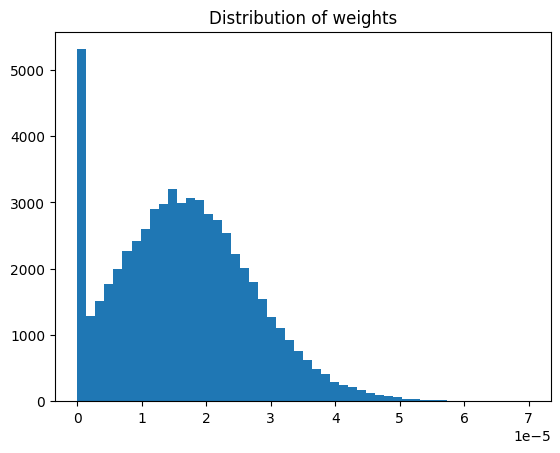

In [51]:
import matplotlib.pyplot as plt
plt.hist(w_estimated, bins=50); plt.title("Distribution of weights"); plt.show()



1.0000000761722025
0.3239999714787844
0.0
0.48644002920299456
1813.6379709899302
[1813.6370752239577, 0.00030510069382922133, 0.0003038790493018984, 0.0003026624702106652, 0.00030145093553879035, 0.00030024442433818923, 0.00029904291577139796, 0.00029784638906841344, 0.00029665482354424, 0.0002954681986169628, 0.00029428649378521074, 0.00029310968863646865, 0.0002919377628145004, 0.000290770696105805, 0.00028960846832577325, 0.00028845105938963227, 0.00028729844931221483, 0.00028615061819750115, 0.00028500754618887694, 0.0002838692135618038, 0.0002827356006449483, 0.00028160668786009197, 0.00028048245571827895, 0.0002793628847857049, 0.0002782479557465676, 0.00027713764932843916, 0.00027603194636725115, 0.0002749308277595989, 0.00027383427451044105, 0.00027274226765799757, 0.00027165478836106596, 0.00027057181785406485, 0.0002694933374077671, 0.0002684193284313631, 0.00026734977235682065, 0.0002662846507463391, 0.00026522394517910635, 0.00026416763737456317, 0.0002631157090803626, 0.0

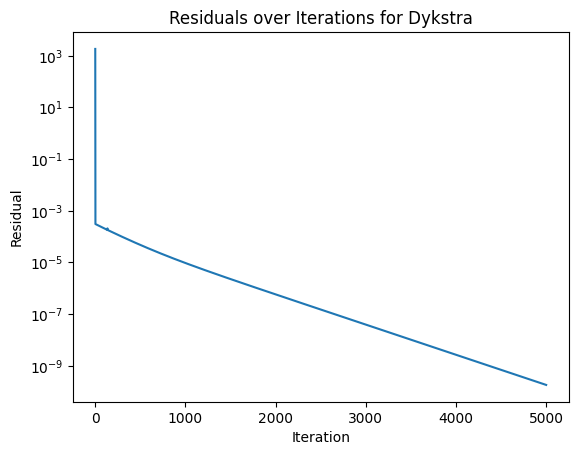

In [81]:
#CVXPY:
lambd = 0.1
beta = 3
# x = 100*np.random.rand(n)
# w = cp.Variable(n,nonneg=True)
# constraints = [cp.sum(w) == 1]
# mean_match = cp.sum_squares(X_train.T @ w - target_mu)
# cov_match = cp.norm(Xc_train.T @ cp.diag(w) @ Xc_train - target_S, 'fro')**2
# for i in range(len((unique_labels))):
#     mask = (Y_train == unique_labels[i]).astype(int)
#     mask = np.reshape(mask, (n, 1))
#     constraints += [mask.T @w >= (labels_frac[i]-lambd)*cp.sum(w)]
#     constraints += [mask.T @w <= (labels_frac[i]+lambd)*cp.sum(w)]
# objective = cp.sum_squares(x-w)
# prob = cp.Problem(cp.Minimize(objective), constraints)
# start_time = time.time()
# prob.solve()
# end_time = time.time()
# print(f"Execution time: {end_time - start_time} seconds")
# wi = sorted(w.value, reverse=True)
# print("Status:", prob.status)
# print("Optimal value:", prob.value)
# print(sum(w.value))
# print(np.max(w.value))
# print(np.min(w.value))
# print(np.linalg.norm(w.value))
# print(np.linalg.norm(w.value-x))
x = 100*np.random.rand(1000)
labels = np.random.randint(0, 4, size=1000)
unique_labels = np.sort(np.unique(labels))
labels_frac   = np.array([np.mean(labels==c) for c in unique_labels])
lambd = 0.1
p_c = labels_frac
classes   = np.unique(labels)
idx_list  = [(labels==c) for c in classes]
lowers    = {c: p_c[c] - lambd for c in classes}
uppers    = {c: p_c[c] + lambd for c in classes}
class_sizes     = {c: mask.sum() for c,mask in zip(classes, idx_list)}  
print()
q,res= project_C(x, classes, idx_list, lowers, uppers, class_sizes, max_iters=5000, tol=1e-24)
print(np.sum(q))
print(np.max(q))
print(np.min(q))
print(np.linalg.norm(q))
print(np.linalg.norm(q-x))
print(res)

plt.plot(range(1, len(res) + 1), res)
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Residuals over Iterations for Dykstra")
plt.yscale("log")
plt.show()




In [80]:
for size in [100, 200, 300]:
    X_train = X_train_full[:size]
    Y_train = Y_train_full[:size]
    X_val = X_val_full[:size]
    Y_val = Y_val_full[:size]
    s = s_full[:size]
    # print(X_train.shape, X_val.shape)
    # print(Y_train.shape, Y_val.shape)

    n = X_train.shape[0]
    XV_mean = np.mean(X_val, axis=0)
    XT_mean = np.mean(X_train, axis=0)
    Xc_train = X_train - XV_mean
    Xc_Val = X_val - XV_mean

    unique_labels = np.sort(np.unique(Y_val).astype(int))
    labels_frac = np.array([(Y_val == unique_labels[i]).sum() for i in range(len(unique_labels))])/len(Y_val)
    # print(labels_frac)

    target_mu = XV_mean
    target_S = Xc_Val.T @ Xc_Val / len(X_val)


    s_obj= (s - s.mean()) / s.std()
    beta = 1
    alpha = 1
    lambd = 0.1
    start_time = time.time()
    w_estimated = fista(X_train, target_mu, target_S, s_obj, alpha, beta, lambd, Y_train, labels_frac, 0.1)
    end_time = time.time()

    print(f"Execution time: {end_time - start_time} seconds")
    #wki = sorted(w_estimated, reverse=True)
    # print("top 15 estimated w:", wki[:5])
    # print(sum(wki))
    # print(min(wki))
    # print(max(wki))
    print(f(w_estimated, X_train, X_train-target_mu, target_mu, beta, target_S, alpha, lambd, s_obj))
    print()

    # #CVXPY:
    w = cp.Variable(n,nonneg=True)
    constraints = [cp.sum(w) == 1]
    mean_match = cp.sum_squares(X_train.T @ w - target_mu)
    cov_match = cp.norm(Xc_train.T @ cp.diag(w) @ Xc_train - target_S, 'fro')**2
    for i in range(len((unique_labels))):
        mask = (Y_train == unique_labels[i]).astype(int)
        mask = np.reshape(mask, (n, 1))
        constraints += [mask.T @w >= (labels_frac[i]-lambd)*cp.sum(w)]
        constraints += [mask.T @w <= (labels_frac[i]+lambd)*cp.sum(w)]
    objective = mean_match + beta*cov_match - alpha* (s_obj@w) + lambd* cp.norm(w, 1)
    prob = cp.Problem(cp.Minimize(objective), constraints)
    start_time = time.time()
    prob.solve()
    end_time = time.time()
    print(f"Execution time: {end_time - start_time} seconds")
    # wi = sorted(w.value, reverse=True)
    # print("Status:", prob.status)
    print("Optimal value:", prob.value)
    # print("top 15 Optimal w:", wi[:5])
    print()

Execution time: 0.12235474586486816 seconds
55.119129574197345

Execution time: 4.271276950836182 seconds
Optimal value: 55.13001456954936

Execution time: 0.1080160140991211 seconds
24.404007082435957

Execution time: 13.907487154006958 seconds
Optimal value: 24.400784198640554

Execution time: 0.15339922904968262 seconds
14.039906338026253

Execution time: 28.635581016540527 seconds
Optimal value: 14.036318010275037

